In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
df = pd.read_csv('data/california_housing.csv')
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [3]:
# Features
X = df.drop("Price", axis=1)

# Target
y = df["Price"]

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


X Shape: (20640, 8)
y Shape: (20640,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)


Train Shape: (14448, 8)
Test Shape : (6192, 8)


In [5]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [6]:
rf_model.fit(X_train, y_train)

print("\nRandom Forest trained successfully!")


Random Forest trained successfully!


In [7]:
predictions = rf_model.predict(X_test)

print(predictions[:10])

[0.49866467 0.73402924 4.87848839 2.67154499 2.35912739 1.70858546
 2.39339444 1.65036541 2.83873717 4.83971781]


In [8]:
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

In [9]:
print("\n===== Random Forest Evaluation =====")

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)


===== Random Forest Evaluation =====
MSE : 0.25449935032603926
RMSE: 0.5044792863201019
MAE : 0.3306803779798193
R2  : 0.8061016582952825


In [10]:
sns.set_theme(style="darkgrid", palette="pastel")

In [11]:
plt.rcParams.update({
    "grid.color": "0.3",
    "axes.facecolor": "#1c1c1c",
    "figure.facecolor": "#121212",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

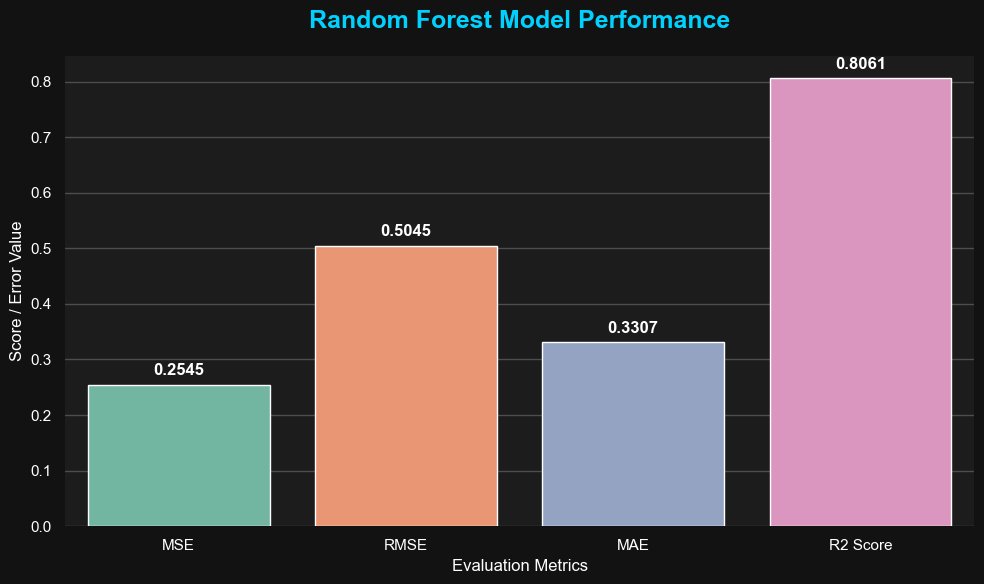

In [13]:
metrics_data = {
    'Metric': ['MSE', 'RMSE', 'MAE', 'R2 Score'],
    'Value': [mse, rmse, mae, r2]
}
df_metrics = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Metric', 
    y='Value', 
    data=df_metrics, 
    hue='Metric',       
    palette='Set2',    
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                color='white',
                fontsize=12,
                fontweight='bold')

plt.title('Random Forest Model Performance', fontsize=18, fontweight='bold', color='#00d1ff', pad=20)
plt.ylabel('Score / Error Value')
plt.xlabel('Evaluation Metrics')

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("reports/images/random_forest_results/performance.png")
plt.show()

In [14]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

      Feature  Importance
0      MedInc    0.538639
5    AveOccup    0.138904
6    Latitude    0.086035
7   Longitude    0.085523
1    HouseAge    0.053347
2    AveRooms    0.043145
4  Population    0.028372
3   AveBedrms    0.026036


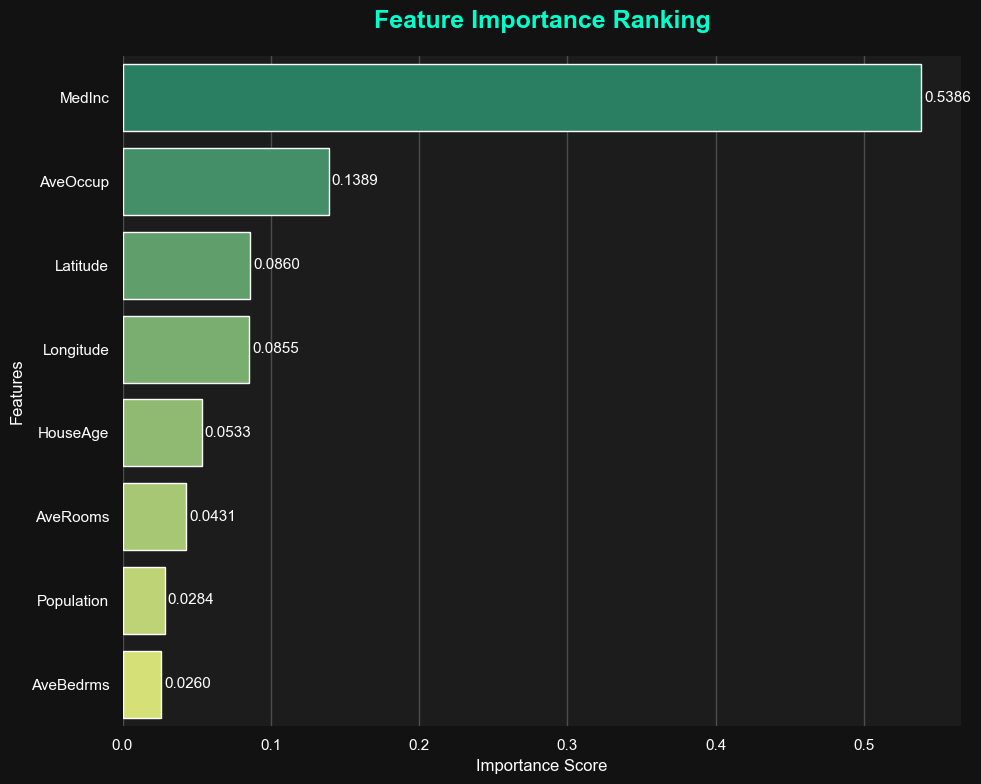

In [19]:
plt.figure(figsize=(10, 8))

ax = sns.barplot(
    x="Importance", 
    y="Feature", 
    data=feature_importance, 
    palette="summer", 
    edgecolor='white',
    hue="Feature"

)

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.002,          
        p.get_y() + p.get_height()/2, 
        f'{width:.4f}',        
        va='center', 
        color='white', 
        fontsize=11
    )

plt.title('Feature Importance Ranking', fontsize=18, fontweight='bold', color='#00ffcc', pad=20)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("reports/images/random_forest_results/feature_importance.png")
plt.show()

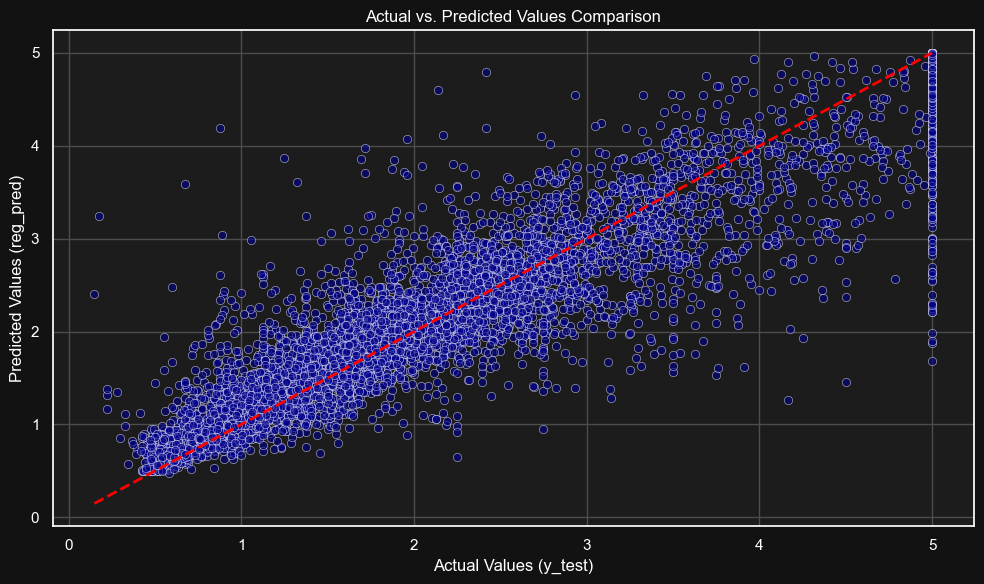

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.6, color='darkblue', edgecolor='w')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (reg_pred)')
plt.title('Actual vs. Predicted Values Comparison')
plt.tight_layout()
plt.savefig("reports/images/random_forest_results/actual_predicted_scatter.png")
plt.show()

# **Residuals**

In [25]:
residuals = y_test - predictions

In [26]:
residuals

20046   -0.021665
3024    -0.276029
15663    0.121522
20484   -0.485545
9814     0.420873
           ...   
17505    0.262026
13512   -0.007962
10842    0.114303
16559   -0.205544
5786    -0.094456
Name: Price, Length: 6192, dtype: float64

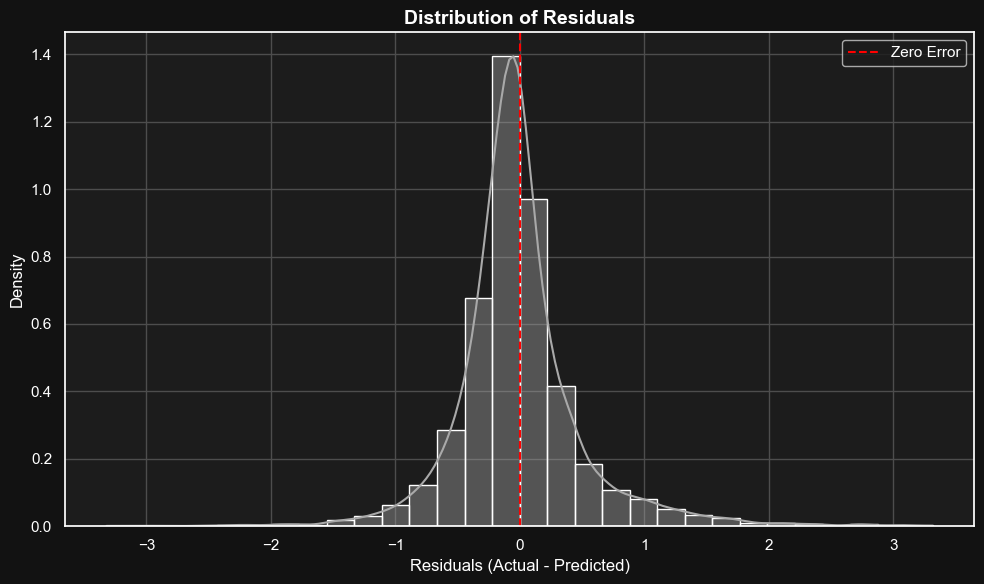

In [29]:
plt.figure(figsize=(10, 6))

# Improve the plot by combining a histogram with a KDE curve
# kde=True: Adds the kernel density estimate line
# stat="density": Normalizes the histogram so the area equals 1
sns.histplot(residuals, kde=True, color='darkgray', bins=30, stat="density", alpha=0.4)

# Add a vertical dashed line at 0
# Ideally, residuals should be normally distributed around zero
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')

# Labeling for clarity
plt.xlabel('Residuals (Actual - Predicted)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribution of Residuals', fontsize=14, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.savefig("reports/images/random_forest_results/residuals.png")
plt.show()

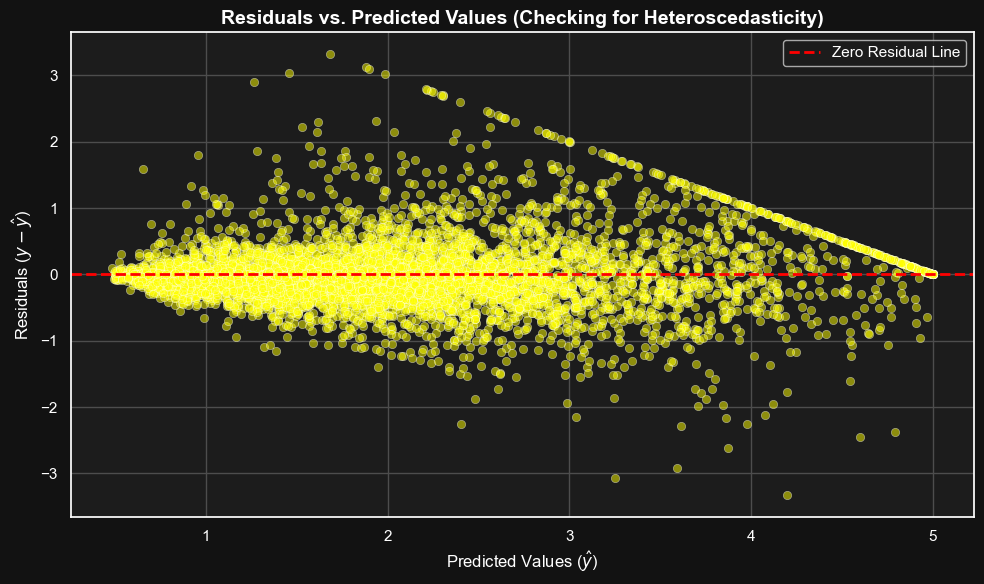

In [36]:
# Scatter plot with respect to prediction and residuals
plt.figure(figsize=(10, 6))

# Use sns.scatterplot for better control over aesthetics
sns.scatterplot(x=predictions, y=residuals, alpha=0.5, color='yellow', edgecolor='w')

# Add a horizontal line at y=0
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual Line')

# FIX: Use 'r' before the string to avoid SyntaxWarning with LaTeX backslashes
plt.xlabel(r'Predicted Values ($\hat{y}$)', fontsize=12)
plt.ylabel(r'Residuals ($y - \hat{y}$)', fontsize=12)

plt.title('Residuals vs. Predicted Values (Checking for Heteroscedasticity)', fontsize=14, fontweight='bold')
plt.legend()
plt.savefig("reports/images/random_forest_results/prediction_residuals_scatter.png")
plt.tight_layout()
plt.show()

In [31]:
joblib.dump(rf_model, "models/random_forest_model/random_forest.pkl")

print("\nModel saved successfully!")


Model saved successfully!


In [33]:
# Load model
model = joblib.load("models/random_forest_model/random_forest.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [34]:
sample = pd.DataFrame({
    "MedInc": [8.3252],
    "HouseAge": [41.0],
    "AveRooms": [6.9841],
    "AveBedrms": [1.0238],
    "Population": [322.0],
    "AveOccup": [2.5556],
    "Latitude": [37.88],
    "Longitude": [-122.23]
})

In [35]:
prediction = model.predict(sample)

print("\nPredicted Price:", prediction[0])


Predicted Price: 4.196023793428929
